# Student Performance Analysis using K-Means Clustering

# **OBJECTIVE**

To identify groups of students with similar academic performance patterns using unsupervised machine learning.


# **Problem Statement**
Schools often have large numbers of students. Identifying groups of students manually is difficult. This project uses clustering to discover naturally occurring groups.

# **Dataset Description**
Number of records: 1000

Features:
- Gender
- Race/Ethnicity
- Parental Education
- Lunch
- Test Preparation Course
- Math Score
- Reading Score
- Writing Score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loding data set

In [2]:
data=pd.read_csv("StudentsPerformance.csv")

In [3]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
data.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

1000 rows 8 columns

In [5]:
data.shape

(1000, 8)

In [6]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


CHECKING NULL VALUES

In [8]:
data.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


#

DUPLICATE CHECK

In [9]:
data.duplicated().sum()

np.int64(0)

# EDA (HISTOGRAM)

# **MATHS SCORE**

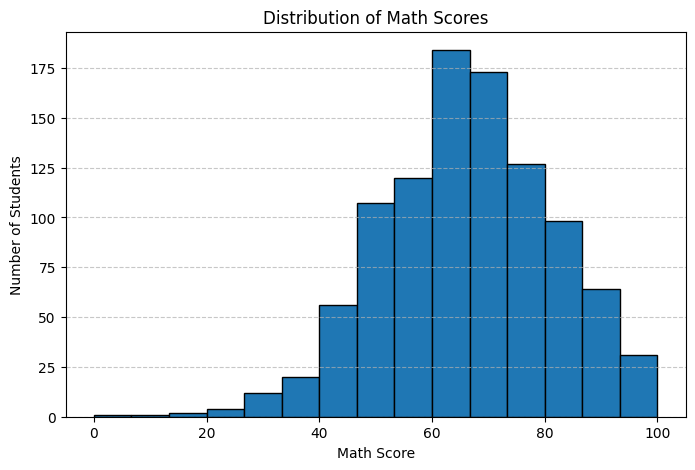

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(data['math score'],
         bins=15,
         edgecolor='black')

plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **observation**
Most students scored between 50-80.


Peak frequency is around 65-70.


Very few students scored extremely low or extremely high.

# **READING SCORE**

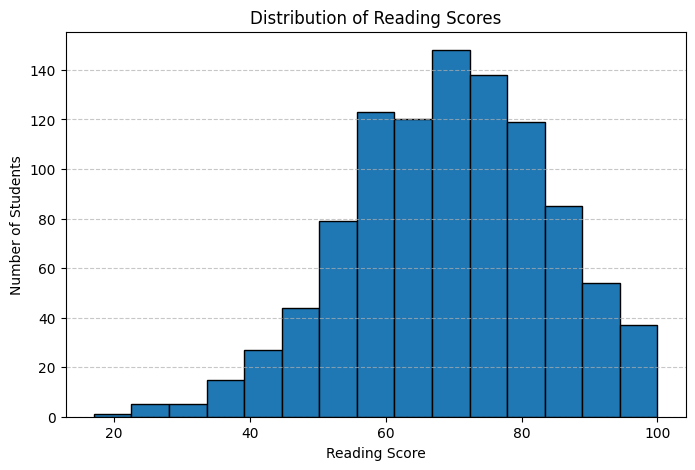

In [11]:
plt.figure(figsize=(8,5))

plt.hist(data['reading score'],
         bins=15,
         edgecolor='black')

plt.title('Distribution of Reading Scores')
plt.xlabel('Reading Score')
plt.ylabel('Number of Students')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **OBSERVATION**


Most students scored between 55-85.


Highest concentration around 70.


No strong skewness visible.

# **WRITING SCORE**

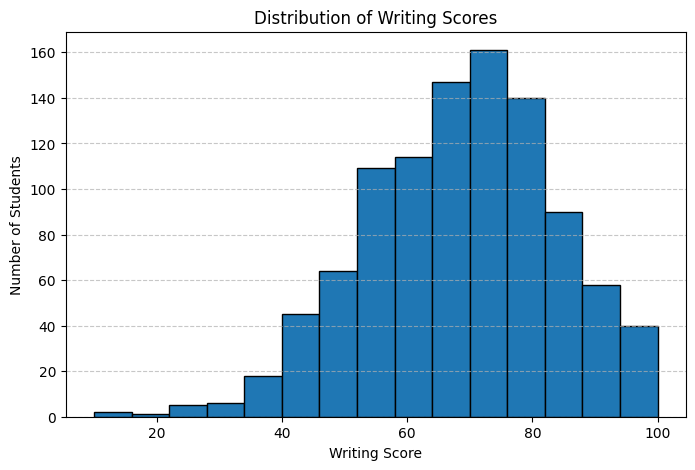

In [12]:
plt.figure(figsize=(8,5))

plt.hist(data['writing score'],
         bins=15,
         edgecolor='black')

plt.title('Distribution of Writing Scores')
plt.xlabel('Writing Score')
plt.ylabel('Number of Students')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **Observation**


Most students scored between 55-85.


Peak frequency around 70-75.


Few extreme observations.

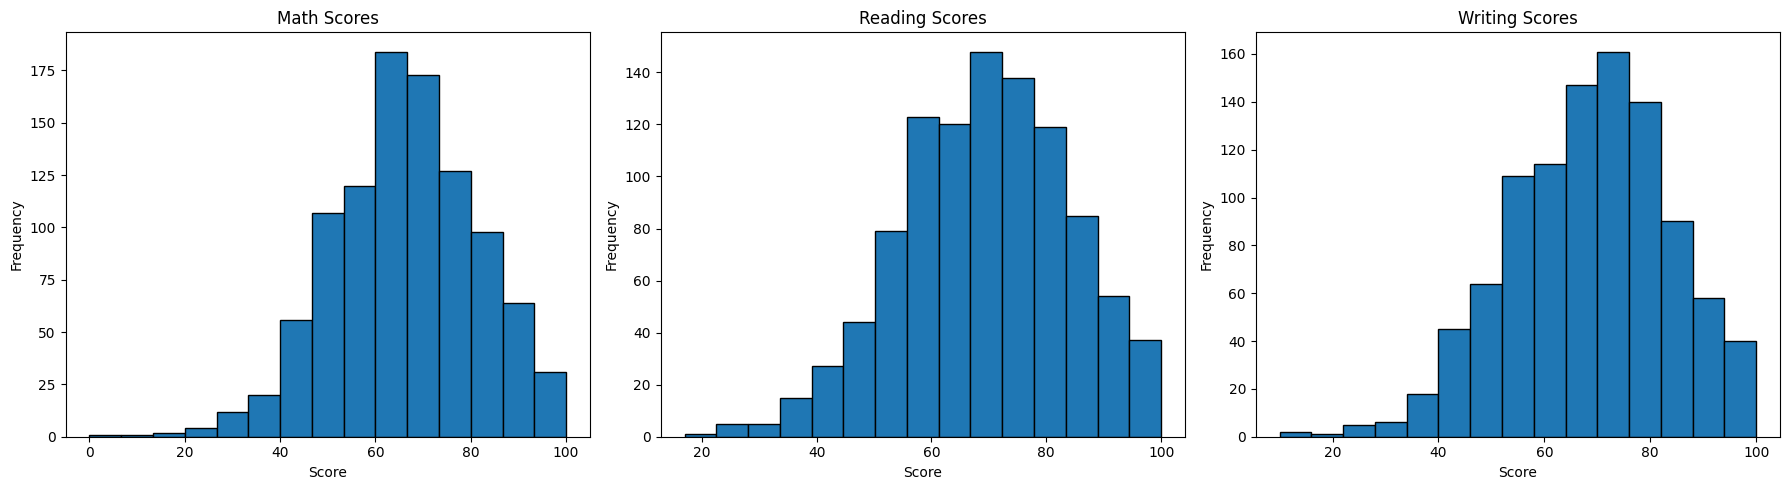

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].hist(data['math score'],
             bins=15,
             edgecolor='black')
axes[0].set_title('Math Scores')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(data['reading score'],
             bins=15,
             edgecolor='black')
axes[1].set_title('Reading Scores')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

axes[2].hist(data['writing score'],
             bins=15,
             edgecolor='black')
axes[2].set_title('Writing Scores')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#**FEATURE ENGINEERING**

CREATING  AN AVG SCORE COLUMN

In [14]:
data['average_score'] = (
    data['math score']
    + data['reading score']
    + data['writing score']
)/3


In [15]:
data.head(30)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,77.333333
6,female,group B,some college,standard,completed,88,95,92,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000
9,female,group B,high school,free/reduced,none,38,60,50,49.333333


# ANALYSIS BETWEEN PARENT LEVEL EDUCATION AND AVG MARKS

In [16]:
data.groupby('parental level of education')[
    ['math score','reading score','writing score','average_score']
].mean().sort_values(by='average_score',ascending=False)

,math score,reading score,writing score,average_score
parental level of education,,,,
master's degree,69.745763,75.372881,75.677966,73.598870
bachelor's degree,69.389831,73.000000,73.381356,71.923729
associate's degree,67.882883,70.927928,69.896396,69.569069
some college,67.128319,69.460177,68.840708,68.476401
some high school,63.497207,66.938547,64.888268,65.108007
high school,62.137755,64.704082,62.448980,63.096939


The analysis indicates a positive association between parental education level and student performance. Students whose parents hold Bachelor's or Master's degrees achieve higher average scores compared to students whose parents have lower educational qualifications. This suggests that parental education may be an important factor influencing academic outcomes.

# ANALYSIS BETWEEN TEST PREPRATION COURSE AND AVG SCORE

In [17]:
data.groupby('test preparation course')['average_score'].mean()

,average_score
test preparation course,
completed,72.669460
none,65.038941


# ANALYSIS BETWEEN LUNCH AND AVG SCORE

In [18]:
data.groupby('lunch')['average_score'].mean()

,average_score
lunch,
free/reduced,62.199061
standard,70.837209


# FEATURE MATRIX
WE USE FATURE MATRIX BECAUSE BECAUSE ML  DONT UNDERSTAND MATH SCORE ETC IT ONLY UNDERSTAND ROWS AND COLUMNS USE THESE THREE COLUMNS FOR CLUSTERING



In [19]:
X = data[['math score',
          'reading score',
          'writing score']]


K-Means uses Euclidean distance to form clusters. Features with larger numerical values can dominate the distance calculation. StandardScaler brings all features to a common scale, ensuring that each feature contributes equally to clustering.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

To find the best number of clusters (K) before applying K-Means clustering.

WCSS measures:

How far points are from their cluster center (centroid).

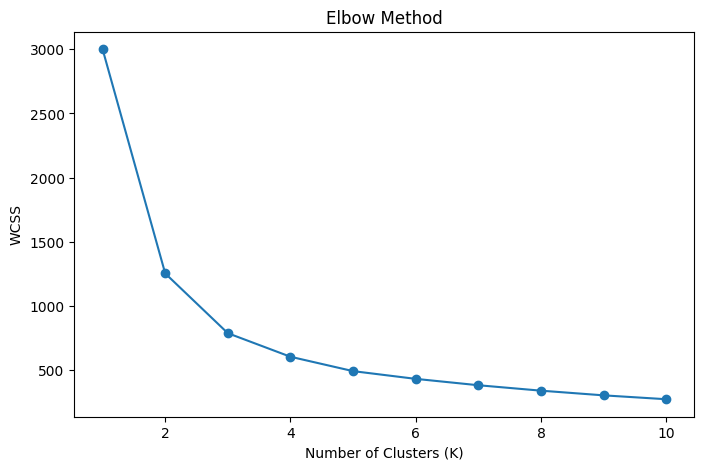

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

data['Cluster'] = kmeans.fit_predict(X_scaled)

In [23]:
data.groupby('Cluster')[
    ['math score',
     'reading score',
     'writing score']
].mean()

,math score,reading score,writing score
Cluster,,,
0,65.338600,68.458239,67.821670
1,48.096386,50.670683,48.485944
2,81.714286,85.146104,84.207792


cluster 2 is high performing students

cluster 1 is low performing students

cluster 0 is the avg performers

The cluster-wise mean scores reveal clear performance differences among student groups. Cluster 2 achieved the highest average scores in mathematics (81.71), reading (85.15), and writing (84.21), indicating a high-performing student group. Cluster 1 had the lowest average scores across all subjects and was identified as the low-performing group. Cluster 0 exhibited moderate average scores and represents average-performing students.

# HOW MANY STUDENTS ARE THEIR IN EACH CLUSTER

In [24]:
data['Cluster'].value_counts()

,count
Cluster,
0,443
2,308
1,249


# MATH SCORE AND READING SCORE CLUSTER PLOT

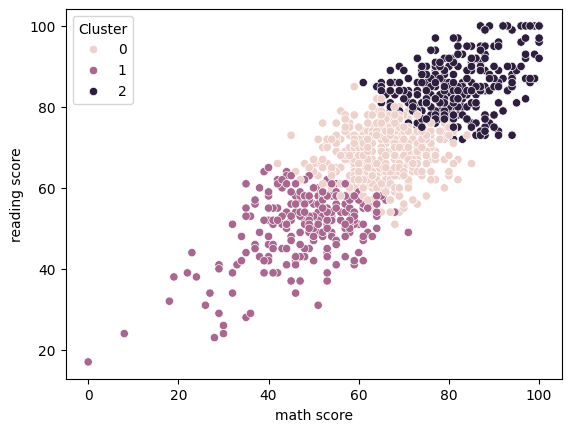

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=data,
    x='math score',
    y='reading score',
    hue='Cluster'
)

plt.show()

# MATH SCORE AND WRITING SCORE CLUSTER PLOT

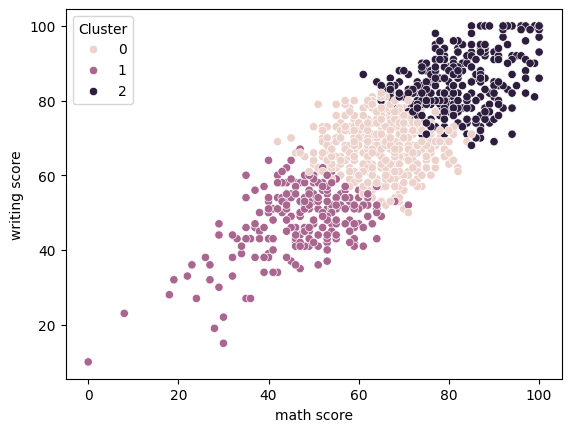

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=data,
    x='math score',
    y='writing score',
    hue='Cluster'
)

plt.show()

# READING SCORE AND WRITING SCORE CLUTER PLOT

<Axes: xlabel='reading score', ylabel='writing score'>

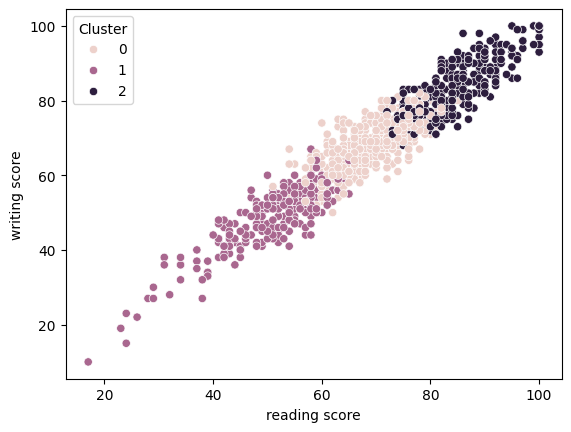

In [27]:
sns.scatterplot(
    data=data,
    x='reading score',
    y='writing score',
    hue='Cluster'
)

# **silhouette_score**
Silhouette Score is a metric used to evaluate the quality of clustering. It measures how similar a data point is to its own cluster compared to other clusters. A higher Silhouette Score indicates that clusters are well separated and internally cohesive, while a lower score suggests overlapping clusters.

In [28]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_scaled,
    data['Cluster']
)

print("Silhouette Score:", round(sil_score,3))

Silhouette Score: 0.406


The Silhouette Score of 0.406 indicates moderate cluster quality. The clusters are reasonably distinct and meaningful, although some overlap exists between adjacent student groups. This is expected because student performance varies continuously rather than forming perfectly separated categories.

# correlation matrix

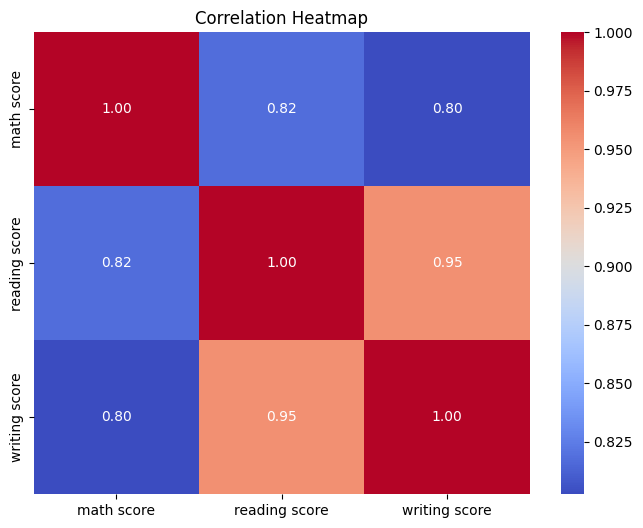

In [29]:
plt.figure(figsize=(8,6))

correlation_matrix = data[
    ['math score',
     'reading score',
     'writing score']
].corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

The heatmap shows strong positive correlations among math, reading, and writing scores. The highest correlation is between reading and writing scores (0.95), indicating that students who perform well in reading generally perform well in writing. This suggests that academic performance tends to be consistent across subjects and supports the formation of meaningful clusters using K-Means.

# **DISTRIBUTION**

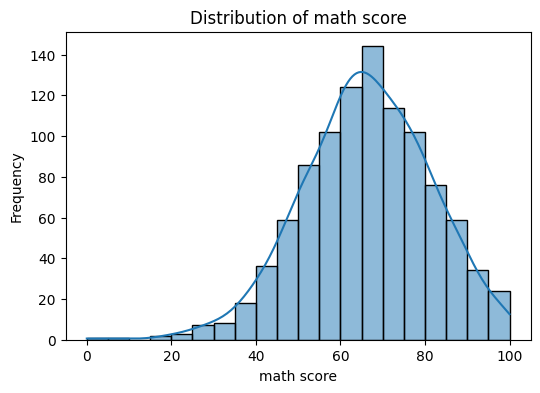

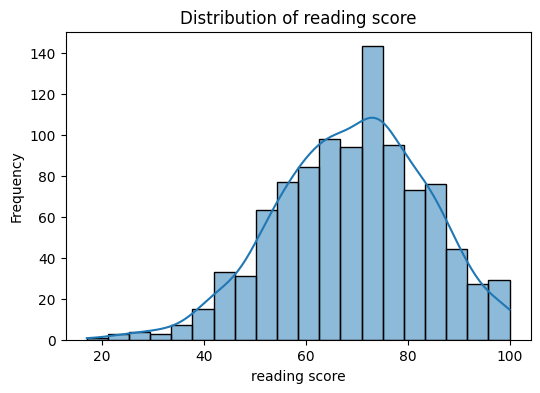

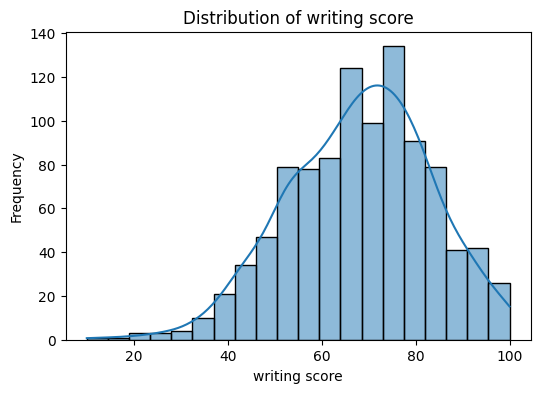

In [30]:
score_columns = ['math score','reading score','writing score']

for col in score_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data[col],
        bins=20,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

The distributions of math, reading, and writing scores are approximately bell-shaped, indicating that most students score around the average range while very low and very high scores are less common. Reading and writing scores are slightly higher than mathematics scores, suggesting students generally perform better in language-based subjects. The absence of multiple peaks indicates that student performance varies continuously rather than forming clearly visible groups.


# **BOX PLOT**

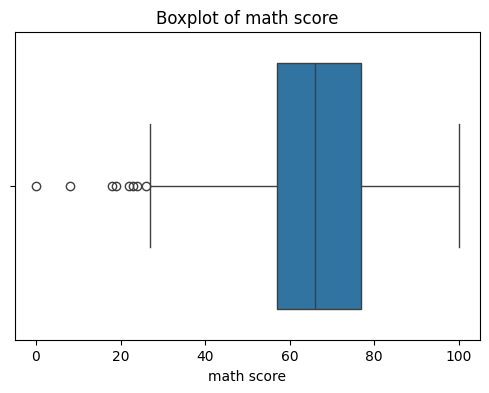

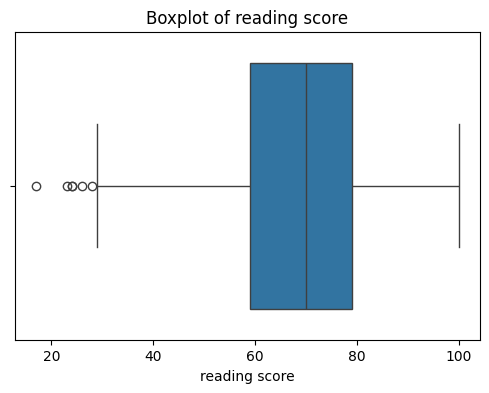

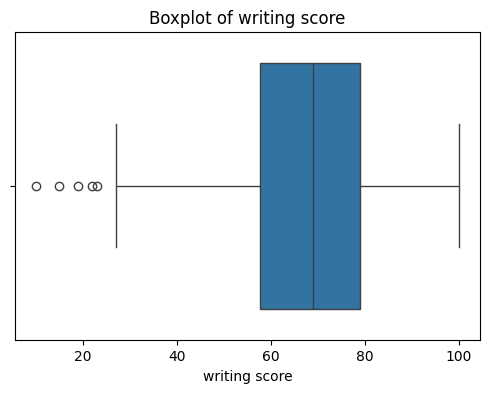

In [31]:
score_columns = ['math score','reading score','writing score']

for col in score_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=data[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

Most students scored between 57 and 77 marks, the typical score is around 67, and a few students scored exceptionally low compared to the rest of the class.

In [32]:
pd.crosstab(
    data['Cluster'],
    data['test preparation course']
)

test preparation course,completed,none
Cluster,,
0,154,289
1,51,198
2,153,155


Students who completed the test preparation course
appear more often in the high-performing cluster.

In [33]:
pd.crosstab(
    data['Cluster'],
    data['parental level of education'],
    normalize='index'
)*100


parental level of education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
Cluster,,,,,,
0,20.090293,12.641084,20.767494,5.191874,25.056433,16.252822
1,21.285141,7.630522,27.710843,3.212851,17.269076,22.891566
2,25.974026,13.961039,11.363636,9.090909,23.376623,16.233766


In [34]:
pd.crosstab(
    data['Cluster'],
    data['lunch'],
    normalize='index'
)*100

lunch,free/reduced,standard
Cluster,,
0,32.731377,67.268623
1,55.823293,44.176707
2,23.051948,76.948052


students in the high performing cluster are much more likely to have standard lunch while students in low performing cluster have much more likely to have free lunch

In [35]:
(data['average_score'] < 50).sum()

np.int64(103)

In [36]:
data['Result'] = data['average_score'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

In [37]:
data['Result'].value_counts()

,count
Result,
Pass,897
Fail,103


In [38]:
pd.crosstab(
    data['Cluster'],
    data['Result']
)

Result,Fail,Pass
Cluster,,
0,0,443
1,103,146
2,0,308


# **CONCLUSION**


The Student Performance dataset was analyzed using K-Means clustering to identify groups of students with similar academic characteristics.

Three clusters were identified:

Cluster 2 represented high-performing students.
Cluster 0 represented average-performing students.
Cluster 1 represented low-performing students.

The analysis showed strong correlations among mathematics, reading, and writing scores. Students who completed test preparation courses were more frequently found in the high-performing cluster. Higher-performing students were also more likely to have standard lunch and parents with higher education levels.

The results demonstrate that clustering can be used to identify meaningful student groups and support educational decision-making.